Importing the important Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score,classification_report,roc_auc_score



import shap
import joblib

c:\Users\evm88\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load the dataset

In [2]:
path = r"D:\Guvi\Final project 1\bank_term_deposit\bank-full.csv"
df = pd.read_csv(path,sep=";")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


Inspecting the dataset

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape

(45211, 17)

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Encoding

In [7]:
print(df['education'].unique())

['tertiary' 'secondary' 'unknown' 'primary']


In [8]:
education_map = {
    'unknown':0,
    'primary':1,
    'secondary':2,
    'tertiary':3
}
df['education'] = df['education'].map(education_map)
print(df['education'].head())

0    3
1    2
2    2
3    0
4    0
Name: education, dtype: int64


Feature Engineering

In [9]:
df['age_balance'] = df['age'] * df['balance']

df['duration_balance'] = (
    df['duration'] * df['balance']
)

df['age_education'] = (
    df['age'] * df['education']
)

df['duration_education'] = (
    df['duration'] * df['education']
)

In [10]:
df.describe()

,age,education,balance,day,duration,campaign,pdays,previous,age_balance,duration_balance,age_education,duration_education
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,4.521100e+04,4.521100e+04,45211.000000,45211.000000
mean,40.936210,2.060516,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,5.892766e+04,3.685937e+05,82.914158,532.461481
std,10.618762,0.778704,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,1.496531e+05,1.187071e+06,36.930534,607.091899
min,18.000000,0.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,-3.355030e+05,-2.697156e+06,0.000000,0.000000
25%,33.000000,2.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,2.660000e+03,8.458500e+03,59.000000,180.000000
50%,39.000000,2.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,1.724900e+04,7.334300e+04,81.000000,352.000000
75%,48.000000,3.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,5.828850e+04,2.950915e+05,105.000000,663.000000
max,95.000000,3.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,6.821136e+06,7.343750e+07,267.000000,14754.000000


In [11]:
df.isnull().sum()

age                   0
job                   0
marital               0
education             0
default               0
balance               0
housing               0
loan                  0
contact               0
day                   0
month                 0
duration              0
campaign              0
pdays                 0
previous              0
poutcome              0
y                     0
age_balance           0
duration_balance      0
age_education         0
duration_education    0
dtype: int64

No null values in this dataset

In [12]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [13]:
df['y'].value_counts(normalize=True)*100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

The dataset is imbalanced

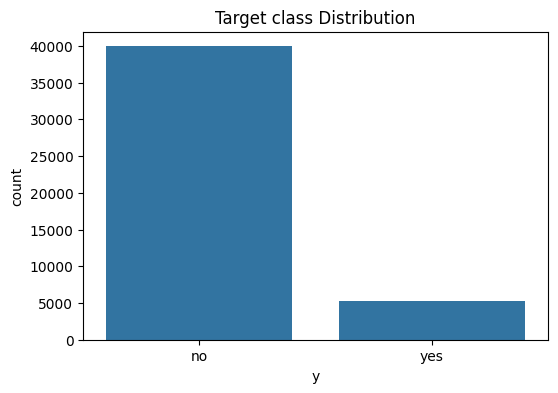

In [14]:
#Visualize the imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Target class Distribution")
plt.show()

In [15]:
#seperate the features and targe
X = df.drop('y', axis=1)
y= df['y']

In [16]:
#Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)
print("Encoded Target Values:")
print(np.unique(y))


Encoded Target Values:
[0 1]


In [17]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'age_balance', 'duration_balance',
       'age_education', 'duration_education'],
      dtype='object')

Encoding

In [18]:
X = pd.get_dummies(
    X,
    columns=[
        'job',
        'marital',  
        'default',
        'housing',
        'loan',
        'contact',
        'month',
        'poutcome'
    ],
    drop_first=True)


In [19]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 44 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   age                 45211 non-null  int64
 1   education           45211 non-null  int64
 2   balance             45211 non-null  int64
 3   day                 45211 non-null  int64
 4   duration            45211 non-null  int64
 5   campaign            45211 non-null  int64
 6   pdays               45211 non-null  int64
 7   previous            45211 non-null  int64
 8   age_balance         45211 non-null  int64
 9   duration_balance    45211 non-null  int64
 10  age_education       45211 non-null  int64
 11  duration_education  45211 non-null  int64
 12  job_blue-collar     45211 non-null  bool 
 13  job_entrepreneur    45211 non-null  bool 
 14  job_housemaid       45211 non-null  bool 
 15  job_management      45211 non-null  bool 
 16  job_retired         45211 non-null  bool

In [20]:
X.columns

Index(['age', 'education', 'balance', 'day', 'duration', 'campaign', 'pdays',
       'previous', 'age_balance', 'duration_balance', 'age_education',
       'duration_education', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_married', 'marital_single', 'default_yes',
       'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown',
       'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown'],
      dtype='object')

Train test split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
) 
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (36168, 44)
Testing shape: (9043, 44)


In [22]:
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

In [23]:
num_cols = [
    'age',
    'education', 
    'balance', 
    'day', 
    'duration', 
    'campaign', 
    'pdays',
    'previous',
    'age_balance',
    'duration_balance',
    'age_education',
    'duration_education'
]

scaler = StandardScaler()
X_train_lr[num_cols] = scaler.fit_transform(X_train_lr[num_cols])
X_test_lr[num_cols] =  scaler.transform(X_test_lr[num_cols])

Logistic Regression

In [24]:
lr_model = LogisticRegression(solver='liblinear',max_iter=5000 , random_state=42)
lr_model.fit(X_train_lr,y_train)

y_pred = lr_model.predict(X_test_lr)
y_prob = lr_model.predict_proba(X_test_lr)[:,1]

print("Accuracy:", accuracy_score(y_test,y_pred))

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test,y_prob))

Accuracy: 0.9019130819418335

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.35      0.46      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043


ROC-AUC Score:
0.9056215990994456


Lgistic Regression Balanced

In [25]:
lr_balanced = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=5000,
    random_state=42
)

lr_balanced.fit(X_train_lr, y_train)

y_pred_bal = lr_balanced.predict(X_test_lr)
y_prob_bal = lr_balanced.predict_proba(X_test_lr)[:,1]

print("Accuracy:", accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred_bal))
print(roc_auc_score(y_test, y_prob_bal))

Accuracy: 0.9019130819418335
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043

0.907917965277523


Random forest

In [26]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.9060046444763906

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.66      0.40      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.72      9043
weighted avg       0.89      0.91      0.90      9043


ROC-AUC Score:
0.9231854860187994


Feature importance

In [27]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)
print(importance.head(10))


               Feature  Importance
4             duration    0.151131
11  duration_education    0.131600
9     duration_balance    0.075823
0                  age    0.064859
2              balance    0.060872
8          age_balance    0.060548
3                  day    0.057873
10       age_education    0.051856
42    poutcome_success    0.046614
6                pdays    0.035059


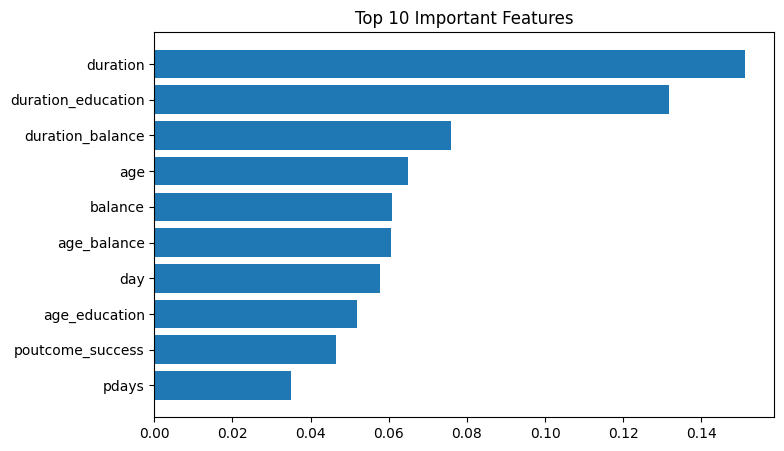

In [28]:
top10 = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

Random Forest Balanced

In [29]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_balanced.fit(X_train,y_train)

y_pred_rf_bal = rf_balanced.predict(X_test)
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf_bal))
print(classification_report(y_test, y_pred_rf_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_bal))

Accuracy: 0.9042353201371226
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.68      0.34      0.46      1058

    accuracy                           0.90      9043
   macro avg       0.80      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043

ROC-AUC: 0.9226427623627951


XGBoost

In [30]:
xgb_model = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss'
)

xgb_model.fit(X_train,y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.9052305650779608

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      7985
           1       0.63      0.47      0.54      1058

    accuracy                           0.91      9043
   macro avg       0.78      0.72      0.74      9043
weighted avg       0.90      0.91      0.90      9043


ROC-AUC Score:
0.9276597306149409


XGBoost Balanced

In [31]:
xgb_balanced = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=7.5
)

xgb_balanced.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.9052305650779608

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      7985
           1       0.63      0.47      0.54      1058

    accuracy                           0.91      9043
   macro avg       0.78      0.72      0.74      9043
weighted avg       0.90      0.91      0.90      9043


ROC-AUC Score:
0.9276597306149409


Feature Importance

In [32]:
importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

print(importance_xgb.head(10))

             Feature  Importance
42  poutcome_success    0.225330
29   contact_unknown    0.084763
4           duration    0.065665
36         month_mar    0.062430
39         month_oct    0.042745
26       housing_yes    0.037689
35         month_jun    0.035324
33         month_jan    0.030034
40         month_sep    0.027901
37         month_may    0.021084


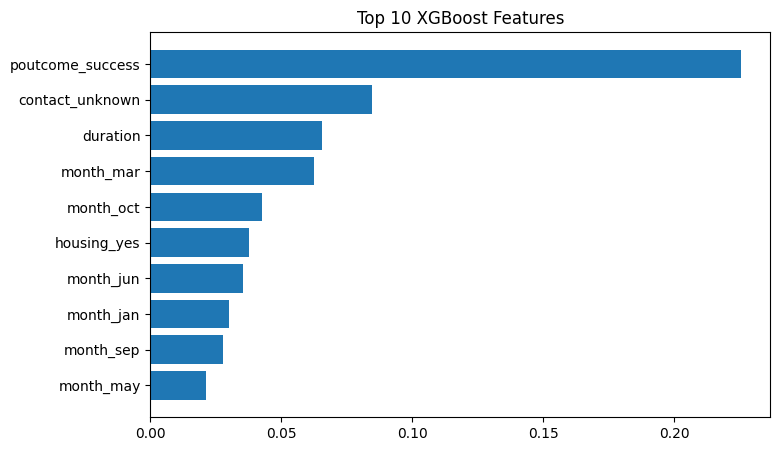

In [33]:
top10 = importance_xgb.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title("Top 10 XGBoost Features")

plt.gca().invert_yaxis()

plt.show()

Gradient Boosting

In [34]:
gb_model = GradientBoostingClassifier(
    random_state=42
)
gb_model.fit(X_train,y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_gb))

Accuracy: 0.9042353201371226

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.40      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043


ROC-AUC Score:
0.9216834376364946


Naive Bayes

In [35]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_nb))

Accuracy: 0.8709499060046445

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      7985
           1       0.43      0.30      0.35      1058

    accuracy                           0.87      9043
   macro avg       0.67      0.62      0.64      9043
weighted avg       0.85      0.87      0.86      9043


ROC-AUC Score:
0.7956569678733638


SVM

In [36]:
svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(X_train_lr, y_train)

y_pred_svm = svm_model.predict(X_test_lr)
y_prob_svm = svm_model.predict_proba(X_test_lr)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_svm))

Accuracy: 0.9015813336282207

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.65      0.34      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.66      0.69      9043
weighted avg       0.89      0.90      0.89      9043


ROC-AUC Score:
0.8908704056400647


LightGBM

In [37]:
lgbm_model = LGBMClassifier(
    random_state=42
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_lgbm))

[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005459 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1926
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116982 -> initscore=-2.021327
[LightGBM] [Info] Start training from score -2.021327
Accuracy: 0.9089903792989052

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.65      0.48      0.55      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.72      0.75      9043
weighted avg       0.90      0.91      0.90      9043


ROC-AUC Score:
0.9345867073541717


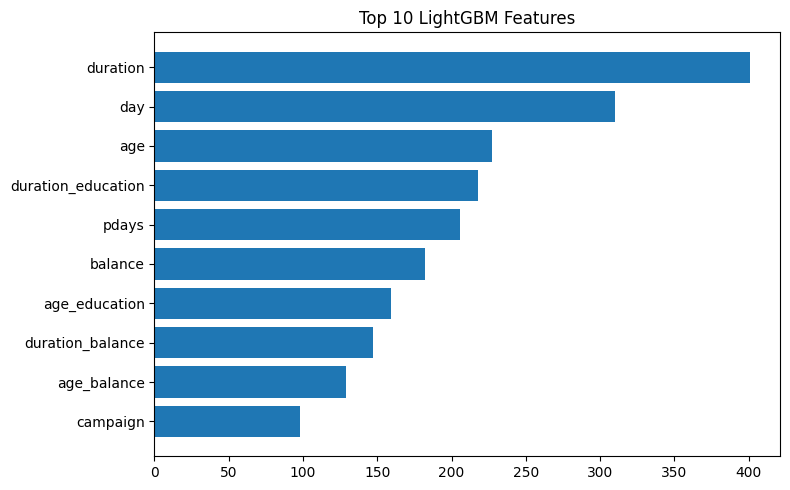

In [38]:
importance_lgbm = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_model.feature_importances_
})

importance_lgbm = importance_lgbm.sort_values(
    by='Importance',
    ascending=False
)

top10 = importance_lgbm.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title("Top 10 LightGBM Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("feature_importance.png")

plt.show()

LightGBM + SMOTE

In [39]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# CLASS WEIGHT BALANCE

pos = sum(y_train == 1)
neg = sum(y_train == 0)
scale_pos_weight = neg / pos


# TRAIN LIGHTGBM

lgbm = LGBMClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

lgbm.fit(X_train_smote, y_train_smote)

# PROBABILITY PREDICTION

y_prob = lgbm.predict_proba(X_test)[:, 1]

#  THRESHOLD TUNING

best_threshold = 0.5
best_f1 = 0
best_y_pred = None

for threshold in np.arange(0.3, 0.6, 0.05):
    y_pred_temp = (y_prob > threshold).astype(int)

    report = classification_report(y_test, y_pred_temp, output_dict=True)
    f1 = report['1']['f1-score']

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_y_pred = y_pred_temp

print("\nBest Threshold:", best_threshold)

#FINAL EVALUATION

print("\nAccuracy:", accuracy_score(y_test, best_y_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_y_pred))

Before SMOTE:
0    31937
1     4231
Name: count, dtype: int64

After SMOTE:
0    31937
1    31937
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 31937, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004776 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2013
[LightGBM] [Info] Number of data points in the train set: 63874, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Best Threshold: 0.5499999999999999

Accuracy: 0.84739577573814

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.91      7985
           1       0.43      0.87      0.57      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.86      0.74      9043
weighted avg 

CatBoost

In [40]:
cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)
y_prob_cat = cat_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_cat))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_cat))

Accuracy: 0.9095432931549264

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.65      0.48      0.55      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.72      0.75      9043
weighted avg       0.90      0.91      0.90      9043


ROC-AUC Score:
0.9325008019526214


Stratified K-Fold

In [41]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    lgbm_model,
    X,
    y,
    cv=skf,
    scoring='roc_auc'
)

print(scores)
print(scores.mean())
print(scores.std())

[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1924
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116982 -> initscore=-2.021327
[LightGBM] [Info] Start training from score -2.021327
[LightGBM] [Info] Number of positive: 4232, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002016 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1924
[LightGBM] [Info] Number of data points in the train set: 36169, number of used features: 44
[LightGBM] [Info] [b

SHAP

In [42]:
explainer = shap.TreeExplainer(lgbm_model)

shap_values = explainer.shap_values(X_test)

c:\Users\evm88\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


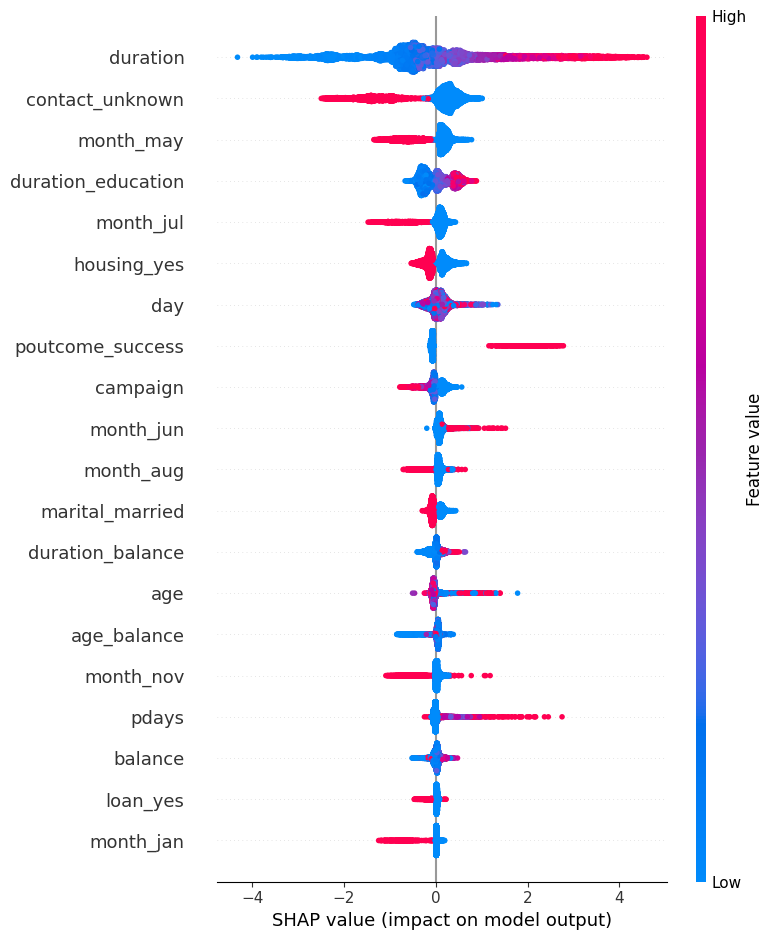

In [43]:
shap.summary_plot(
    shap_values,
    X_test
)

stack model



In [44]:
estimators = [
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('lgbm', lgbm_model)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)

y_pred_stack = stack_model.predict(X_test)
y_prob_stack = stack_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_stack))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_stack))

[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002555 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1926
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116982 -> initscore=-2.021327
[LightGBM] [Info] Start training from score -2.021327
[LightGBM] [Info] Number of positive: 3385, number of negative: 25549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001749 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1920
[LightGBM] [Info] Number of data points in the train set: 28934, number of used features: 44
[LightGBM] [Info] [b

In [45]:
# Get probabilities from base models

rf_prob = rf_model.predict_proba(X_test)[:,1]

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

lgbm_prob = lgbm_model.predict_proba(X_test)[:,1]

# Simple weighted blending

blend_prob = (
    0.2 * rf_prob +
    0.3 * xgb_prob +
    0.5 * lgbm_prob
)

# Convert probabilities to predictions

blend_pred = (blend_prob >= 0.5).astype(int)

print("Accuracy:",
      accuracy_score(y_test, blend_pred))

print("\nClassification Report:")
print(classification_report(y_test, blend_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, blend_prob))

Accuracy: 0.9097644586973349

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.66      0.47      0.55      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.72      0.75      9043
weighted avg       0.90      0.91      0.90      9043


ROC-AUC:
0.9352588087541267


In [46]:
joblib.dump(lgbm_model, "lightgbm_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [47]:
print(X.columns.tolist())

['age', 'education', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'age_balance', 'duration_balance', 'age_education', 'duration_education', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


In [48]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [54]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Naive Bayes",
        "SVM",
        "XGBoost",
        "CatBoost",
        "LightGBM",
        "LightGBM + SMOTE",
        "Stacking",
        "Blending"
    ],

    "Accuracy": [
        0.9019,
        0.9060,
        0.9042,
        0.8709,
        0.9016,
        0.9052,
        0.9095,
        0.9090,
        0.8474,
        0.9102,
        0.9098
    ],

    "Precision": [
        0.65,
        0.66,
        0.65,
        0.43,
        0.65,
        0.63,
        0.65,
        0.65,
        0.43,
        0.66,
        0.66
    ],

    "Recall": [
        0.35,
        0.40,
        0.40,
        0.30,
        0.34,
        0.47,
        0.48,
        0.48,
        0.87,
        0.48,
        0.47
    ],

    "F1_Score": [
        0.46,
        0.50,
        0.49,
        0.35,
        0.44,
        0.54,
        0.55,
        0.55,
        0.57,
        0.56,
        0.55
    ],

    "ROC_AUC": [
        0.9056,
        0.9232,
        0.9217,
        0.7957,
        0.8909,
        0.9277,
        0.9325,
        0.9346,
        0.9238,
        0.9347,
        0.9353
    ]
})

comparison = comparison.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

comparison["Rank"] = range(1, len(comparison) + 1)

comparison = comparison[
    [
        "Rank",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ]
]

print(comparison)

    Rank                Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC
0      1             Blending    0.9098       0.66    0.47      0.55   0.9353
1      2             Stacking    0.9102       0.66    0.48      0.56   0.9347
2      3             LightGBM    0.9090       0.65    0.48      0.55   0.9346
3      4             CatBoost    0.9095       0.65    0.48      0.55   0.9325
4      5              XGBoost    0.9052       0.63    0.47      0.54   0.9277
5      6     LightGBM + SMOTE    0.8474       0.43    0.87      0.57   0.9238
6      7        Random Forest    0.9060       0.66    0.40      0.50   0.9232
7      8    Gradient Boosting    0.9042       0.65    0.40      0.49   0.9217
8      9  Logistic Regression    0.9019       0.65    0.35      0.46   0.9056
9     10                  SVM    0.9016       0.65    0.34      0.44   0.8909
10    11          Naive Bayes    0.8709       0.43    0.30      0.35   0.7957


Best overall model: Blending (ROC-AUC = 0.9353)

Best deployed model: LightGBM (ROC-AUC = 0.9346)

In [55]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)